# CS171-EE142 - Fall 2024 - Homework 2

# Due: Friday, October 18, 2024 @ 11:59pm

### Maximum points: 100 pts


## Submit your solution to Gradescope:
1. Submit a single PDF to **HW2**
2. Submit your jupyter notebook to **HW2-code**

**See the additional submission instructions at the end of this notebook**


## Enter your information below:

### Your Name (submitter): Aamir Khan

### Your student ID (submitter): 862400489
    
    
<b>By submitting this notebook, I assert that the work below is my own work, completed for this course.  Except where explicitly cited, none of the portions of this notebook are duplicated from anyone else's work or my own previous work.</b>


## Academic Integrity
Each assignment should be done  individually. You may discuss general approaches with other students in the class, and ask questions to the TAs, but  you must only submit work that is yours . If you receive help by any external sources (other than the TA and the instructor), you must properly credit those sources, and if the help is significant, the appropriate grade reduction will be applied. If you fail to do so, the instructor and the TAs are obligated to take the appropriate actions outlined at http://conduct.ucr.edu/policies/academicintegrity.html . Please read carefully the UCR academic integrity policies included in the link.


# Overview
In this assignment you will explore some basic computations on data and build a nearest neighbor classifier.  

For this assignment we will use the functionality of Pandas (https://pandas.pydata.org/), Matplotlib (https://matplotlib.org/), and Numpy (http://www.numpy.org/). You may also find Seaborn (https://seaborn.pydata.org/) useful for some data visualization.

If you are asked to **implement** a particular functionality, you should **not** use an existing implementation from the libraries above (or some other library that you may find). When in doubt, please ask.

Before you start, make sure you have installed all those packages in your local Jupyter instance

## Read *all* cells carefully and answer all parts (both text and missing code)

You will complete all the code marked `TODO` and answer descriptive/derivation questions


In [82]:
# Standard library imports.
import random as rand
from collections import Counter

# Related third party imports.
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Local application/library specific imports.
# import here if you write .py script

# Getting real data
In this assignment we are going to use the [penguins dataset](https://github.com/allisonhorst/palmerpenguins).

[More info](https://twitter.com/allison_horst/status/1270046399418138625?ref_src=twsrc%5Etfw%7Ctwcamp%5Etweetembed%7Ctwterm%5E1270046399418138625%7Ctwgr%5E4eb4ba5263d32f342d1474db5259af92ae2c33d3%7Ctwcon%5Es1_&ref_url=https%3A%2F%2Fwww.meganstodel.com%2Fposts%2Fno-to-iris%2F)

<img src="https://github.com/allisonhorst/palmerpenguins/raw/main/man/figures/logo.png" height="200" />

<img src="https://github.com/allisonhorst/palmerpenguins/raw/main/man/figures/lter_penguins.png" height="200" />

<img src="https://github.com/allisonhorst/palmerpenguins/raw/main/man/figures/culmen_depth.png" height="200" />

This dataset can also be easily imported from seaborn
https://github.com/mwaskom/seaborn-data

In [85]:
data = sns.load_dataset("penguins") # load penguins dataset from seaborn
data = data.dropna() # drop samples with missing values (NaN)
data

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


This data has 344 samples and we keep the 333 samples without missing values

We will treat `'species'` as the label for each data sample and remaining 6 entries as the features `['island', 'bill_length_mm','bill_depth_mm','flipper_length_mm', 'body_mass_g', 'sex']`.

The `'species'` label has three possible values `['Adelie', 'Chinstrap', 'Gentoo']`.

**Note** *that the arrangement of data samples is different from the notation we used in the class. In the class, data samples are given as column vectors. Here data samples are given as row vectors. `data` has 333 sample vectors, each of length 6 and stored as rows of `data`.*


In this homework, we will only focus on the 4 **numerical features**.
We can visualize pair-wise relations among 4 numerical features
`['bill_length_mm','bill_depth_mm','flipper_length_mm', 'body_mass_g']` in the data using scatterplot of all pairs of features and color the points by class label.

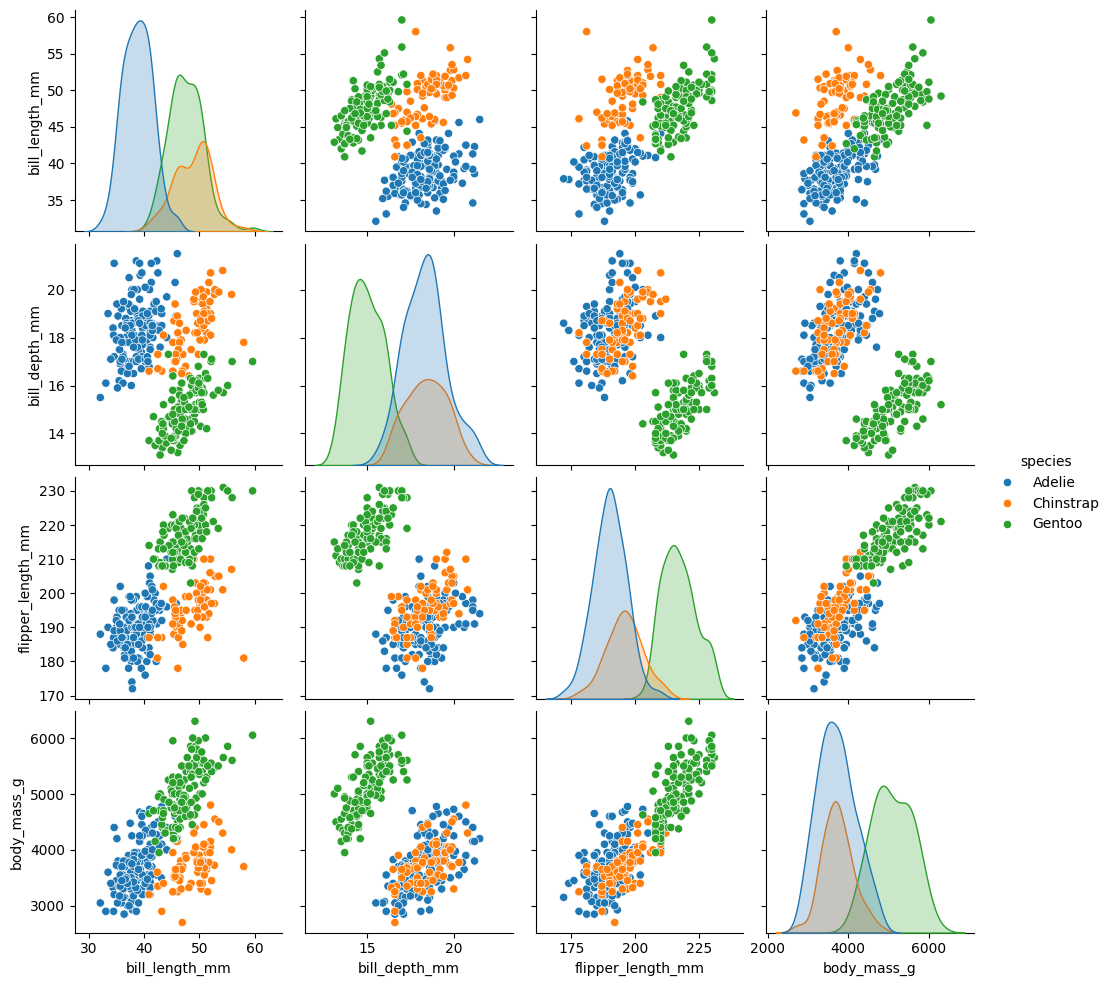

In [86]:
fig = sns.pairplot(data, hue="species")

## Question 1: Basic data analysis [25 pts]

### Question 1a: Counting and simple statistics [5]

1. Calculate and print the min, max, and mean values of each of the four features in the entire dataset [1]

1. Count and print the number of samples that belong to each of the three categories [1]

1. Calculate and print the mean of each feature for each label as a $3\times 4$ table [3]

*Note: For **mean** values, keep 1 digit after the decimal point when printing*

In [87]:
# TODO: complete the code blocks below

print("\n1. print min, max, mean values of 4 features:\n")
features = ['bill_length_mm','bill_depth_mm','flipper_length_mm', 'body_mass_g']
for feature in features:
    # TODO: Calculate and print the min, max, and mean values of each of the four features in the entire dataset
    min = data[feature].min()
    max = data[feature].max()
    mean = data[feature].mean()
        
    print(f"(min, max, mean) of {feature}: ({min}, {max}, {mean:.1f})")
    pass


print("\n2. print number of samples per category:\n")
categories = ['Adelie', 'Chinstrap', 'Gentoo']
for category in categories:
    # TODO: Count and print the number of samples that belong to each of the three categories
    count = Counter(data['species'])
    print(f"number of samples in {category}: {count[category]}")
    pass


print("\n3. print a 3x4 table of mean value of feature for each label:\n")
table = {'bill_length_mm': [], 
         'bill_depth_mm': [], 
         'flipper_length_mm': [], 
         'body_mass_g': []}
for category in categories:
    # TODO: Calculate and print the mean of each feature for each label as a  3×4  table:
    # We filter our data to only include the data relevant to the current category.
    filtered_data = data[data['species'] == category]
    # We calculate the mean of each feature in our filtered data.
    for feature in features:
        feature_mean = filtered_data[feature].mean()
        table[feature].append(feature_mean) # Adding the mean of each feature to our table for the current category.
    pass

pd.set_option("display.precision", 1)
panda_table = pd.DataFrame(data = table, index = categories, columns = features)
panda_table


1. print min, max, mean values of 4 features:

(min, max, mean) of bill_length_mm: (32.1, 59.6, 44.0)
(min, max, mean) of bill_depth_mm: (13.1, 21.5, 17.2)
(min, max, mean) of flipper_length_mm: (172.0, 231.0, 201.0)
(min, max, mean) of body_mass_g: (2700.0, 6300.0, 4207.1)

2. print number of samples per category:

number of samples in Adelie: 146
number of samples in Chinstrap: 68
number of samples in Gentoo: 119

3. print a 3x4 table of mean value of feature for each label:



,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
Adelie,38.8,18.3,190.1,3706.2
Chinstrap,48.8,18.4,195.8,3733.1
Gentoo,47.6,15.0,217.2,5092.4


### Question 1b: Implement the $\ell_p$ distance function [10]
1. Write code that implements the $\ell_p$ distance function between two data points as we saw it in class [7] \\
$\ell_p$ distance between two vectors $\mathbf{x}_i, \mathbf{x}_j$ in $\mathbb{R}^d$ can be written as  
$$\|\mathbf{x}_i - \mathbf{x}_j\|_p = \left(\sum_{k=1}^d |\mathbf{x}_i(k) - \mathbf{x}_j(k)|^p\right)^{1/p}. $$
You should implement this function yourself. Do not use any built-in function to compute distance or norm.

2. Verify that it is correct by comparing it for p=1 and p=2 against an existing implementation in Numpy for the two selected data points below. Note that the difference of the distances may not be exactly 0 due to numerical precision issues. [3]

In [88]:
# TODO: complete the function below
def distance(x,y,p=2):
    """calculates Lp distance between point x and point y
    Args:
        x (np.ndarray): datapoint x
        y (np.ndarray): datapoint y
        p (int): order of Lp norm
    """

    res = (np.sum(np.abs(x-y) ** p)) ** (1/p)
    return res


# TODO: randomly pick 2 samples from the dataset (only keep the numerical features)
x = data.iloc[rand.randint(0,len(data)-1)][2:6] # we only want the numerical features
y = data.iloc[rand.randint(0,len(data)-1)][2:6] # these are in columns at index 2 to 5

# calculate the distance and compare with numpy built-in function to verify your implementation
p = 2
dist = distance(x,y,p)

# dist = ...
print(f"my l_{p} distance: {dist}")

# TODO: verify using numpy built-in function
dist_np = np.linalg.norm(x-y, ord=p)
print(f"numpy l_{p} distance: {dist_np}")

p = 1
dist = distance(x,y,p)

# dist = ...
print(f"my l_{p} distance: {dist}")

# TODO: verify using numpy built-in function
dist_np = np.linalg.norm(x-y, ord=p)
print(f"numpy l_{p} distance: {dist_np}")

my l_2 distance: 1350.1967597354098
numpy l_2 distance: 1350.1967597354098
my l_1 distance: 1374.7
numpy l_1 distance: 1374.7


### Question 1c: Compute the distance matrix between all data points [10]
1. Compute an $N\times N$ distance matrix between all data points (where $N=333$ is the number of data points). Use the distance function you defined in the previous cell. [3]
2. Plot the above matrix and include a colorbar. [3]


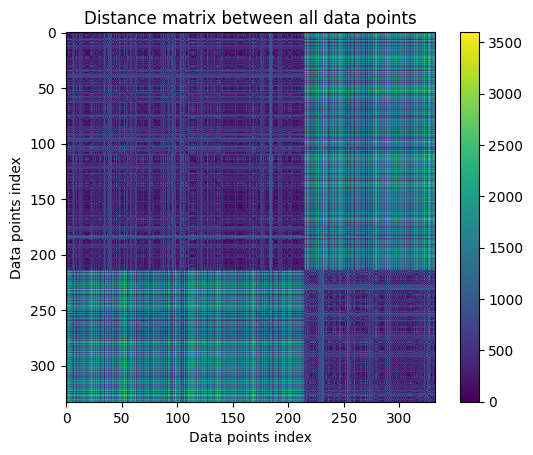

In [89]:
# TODO
# Write your code here
features_data = data[features]
features_data = np.array(features_data)
N, p = 333, 2

# dist_matrix = ...
dist_matrix = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        dist_matrix[i][j] = distance(features_data[i], features_data[j], p)
        #print(dist_matrix[i][j])

# Plot the distance matrix
plt.imshow(dist_matrix, cmap='viridis')
plt.colorbar()
plt.title("Distance matrix between all data points")
plt.xlabel("Data points index")
plt.ylabel("Data points index")
plt.show()

3. What is the minimum number of distance computations that you can do in order to populate every value of this matrix? (note: it is OK if in the first two questions you do all the $N^2$ computations) [2]
**Answer:** The minimum number of distance computations we can do in order to populate every value of this matrix is $N^2 - N$, if we choose not to compute any of the diagonal entries. However, we can also see that our distance computations are symmetric about the main diagonal. With this in mind, we could also just compute the entries on one side of the main diagonal and just mirror our computations about the main diagonal. This would correspond to roughly $\lfloor(N^2/2)\rfloor$ distance computations. This is because the distance between vectors x and y is the same as the distance between the vectors y and x.

4. Do you see any pattern in the distance matrix? Why? [2]
**Answer:** The pattern we see in the distance matrix is that the main diagonal will always be populated with zeros. The reason being is that the distance between any data point and itself will always be zero. This is why we see a distinguishable purple line along the main diagonal which shows us that the main diagonal is filled with zeros. We also see some rectangular sections with clear borders. Around the lower left of our plot, we see higher values which correspond to larger distances. We see a similar pattern in the upper right of our plot. One other observation we can make is that our data is symmetric about the main diagonal. This is why our data looks mirrored about the main diagonal.

## Question 2: K-Nearest Neighbors Classifier [50 pts]
The K-Nearest Neighbors Classifier is one of the most popular instance-based (and in general) classification models. In this question, we will implement our own version and test in different scenarios.

### Question 2a: Implement the K-NN Classifier [15]
For the implementation, your function should have the format:
```python
def knnclassify(test_data,training_data, training_labels, K=1):
```
where `test_data` contains test data points, `training_data` contains training data points, `training_labels` holds the training labels, and `K` is the number of neighbors.

The output of this function should be `pred_labels` which contains the predicted label for each test data point (it should, therefore, have the same number of rows as `test_data`).


In [90]:
# prepare datasets, convert to numpy array, X - data values, Y - labels
X = data[['bill_length_mm','bill_depth_mm','flipper_length_mm', 'body_mass_g']].values
all_labels = data['species'].values
unique_labels = np.unique(all_labels)
new_labels = np.zeros(len(all_labels))
for i in range(0,len(unique_labels)):
  new_labels[all_labels == unique_labels[i]] = i
Y = new_labels

In [91]:
# TODO: complete the function below

def knnclassify(test_data, training_data, training_labels, K=1):
  """KNN classifier
    Args:
      test_data (numpy.ndarray): Test data points.
      training_data (numpy.ndarray): Training data points.
      training_labels (numpy.ndarray): Training labels.
      K (int): The number of neighbors.

    Returns:
      pred_labels: contains the predicted label for each test data point, have the same number of rows as 'test_data'
  """

  pred_labels = np.array([])
  
  for data_point in test_data:
    # we want to first calculate the distance to every other data point in our training data
    distances = np.array([])
    for point in training_data:
      dist = distance(data_point, point, p=2)
      distances = np.append(distances, dist)
    # we want to sort the distances by their indices
    sorted_indices = distances.argsort()
    # We want to count the frequency of each unique label that appears in the knn's.
    label_freqs = {label: 0 for label in unique_labels}
    for i in range(K):
      # we increment the frequency of the label of the ith nearest neighbor (from our training labels)
      label_freqs[unique_labels[int(training_labels[sorted_indices[i]])]] += 1
    # we store the majority label.
    majority_label = 'Adelie' # we'll initialize this to the first label
    for label in unique_labels:
      if label_freqs[label] > label_freqs[majority_label]:
        majority_label = label
    # storing the majority label for this data point using 0 = Adeline, 1 = Chinstrap, 2 = Gentoo
    label_nums = {unique_labels[i]: i for i in range(len(unique_labels))}
    pred_labels = np.append(pred_labels, label_nums[majority_label])

  return pred_labels


### Question 2b: Measuring performance [15]

In this question you will have to evaluate the average performance of your classifier for different values of $K$. In particular, $K$ will range in $\{1,\cdots,10\}$. We are going to measure the performance using classification accuracy. For computing the accuracy, you may use
```python
accuracy = sum(test_labels == pred_labels)/len(test_labels)
```
where `test_labels` are the actual class labels and `pred_labels` are the predicted labels


In order to get a proper estimate for the accuracy for every K, we need to run multiple iterations where for each iteration we get a different randomized split of our data into train and test. In this question, we are going to run 100 iterations for every K, and for every random splitting, you may use:

```python
(training_data, test_data, training_labels, test_labels) = train_test_split(X, Y, test_size=0.3)
```
where the train/test ratio is 70/30.

After computing the accuracy for every $K$ for every iteration, you will have 100 accuracies per $K$. The best way to store those accuracies is in a matrix that has as many rows as values for $K$ and 100 columns, each one for each iteration.

Compute average accuracy as a function of $K$. Because we have a randomized process, we also need to compute how certain/uncertain our estimation for the accuracy per $K$ is. For that reason, we also need to compute the standard deviation of the accuracy for every $K$. Having computed both average accuracy and standard deviation, make a figure that shows the average accuracy as a function of $K$ with each point of the figure being surrounded by an error-bar encoding the standard deviation. You may find
```python
plt.errorbar()
```
useful for this plot.

[0.8297 0.784  0.7659 0.7522 0.7622 0.7599 0.7683 0.7624 0.7606 0.7523]


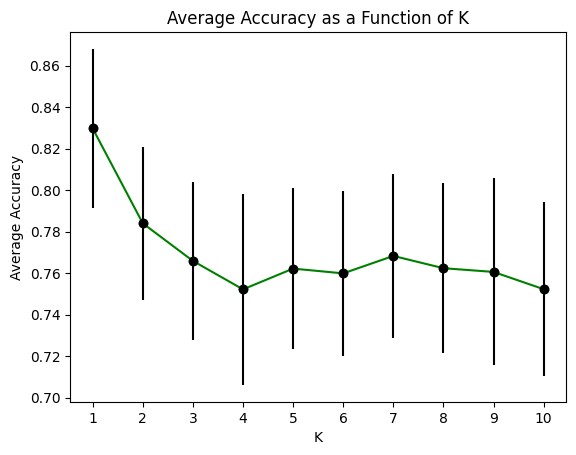

In [9]:
# TODO: write your code here
# we now want to use our knn classifier on this data
trials, num_K = 100, 10
accuracies = np.zeros((num_K, trials))
std_devs = np.zeros(num_K)

for K in range(1,num_K+1):
    for i in range(trials):
        (training_data, test_data, training_labels, test_labels) = train_test_split(X, Y, test_size=0.3)
        pred_labels = knnclassify(test_data, training_data, training_labels, K)
        accuracy = sum(test_labels == pred_labels)/len(test_labels)
        accuracies[K-1][i] = accuracy
    std_devs[K-1] = np.std(accuracies[K-1])

# TODO: plot the avg. accuracies as a function of K and standard deviations
avg_accuracies = np.mean(accuracies, axis=1)

print(avg_accuracies)
# we now want to plot the avg. accuracies as a fnc. of k. (using green circles as our markers)
plt.plot(range(1, num_K+1), avg_accuracies, 'go-')
plt.xlabel('K')
plt.ylabel('Average Accuracy')
plt.xticks(range(1, num_K+1))
plt.title('Average Accuracy as a Function of K')
plt.errorbar(range(1, num_K+1), avg_accuracies, yerr=std_devs, fmt='o', color='black')
plt.show()


# You should be able to get above 80% accuracies

### Question 2c: Effect of data normalization [10]

You will notice that if you compute distances using the raw data, the KNN accuracy will be in 77-83% range.

You can improve the accuracy of the KNN algorithm to above 95% by performing data normalization as the pre-processing step where you can first convert every feature value to the range [0,1] and then perform KNN algorithm.

You can read more about such normalization procedures [here](https://en.wikipedia.org/wiki/Feature_scaling).

1. First normalize the feature values to [0, 1]. Then run KNN similar to question 2b for K = {1, ..., 10} and 100 iterations for every K. Plot the performance with errorbar. [8]

2. Why does the performance increase when we do feature normalization? [2]
**Answer:** Performance increases when we do feature normalization because normalization allows us to more fairly and accurately measure the contribution of each feature. Without normalization, some features that have drastically varying ranges may contribute more to the Euclidean distance than other features. As a result, such distances would be dictated by these features, not accurately representing our data. With normalization, our KNN classifier does a better job at predicting labels as our data is more accurately represented with its proportional contributions to the distance formula.

[0.9814 0.9797 0.9862 0.985  0.986  0.9807 0.9833 0.9785 0.9833 0.9776]


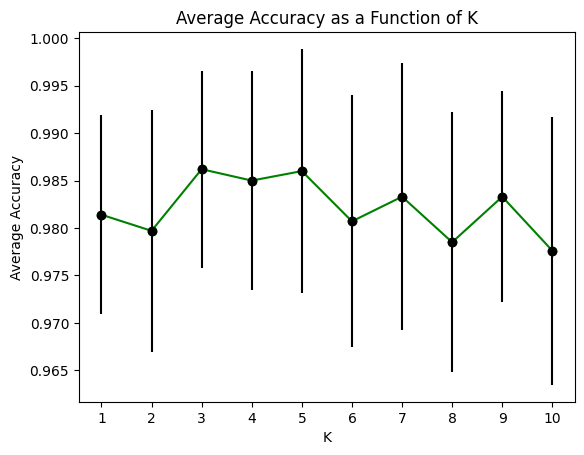

In [10]:
# TODO: Write your code here
trials, num_K = 100, 10
accuracies = np.zeros((num_K, trials))
std_devs = np.zeros(num_K)

# Normalization:
# Let's first get the min and max values of each feature
mins = np.min(X, axis=0)
maxes = np.max(X, axis=0)
# we now want to normalize our features
for i in range(len(X)):
    X[i] = (X[i] - mins) / (maxes - mins)

# We can now use our knn classifier on our normalized data.
for K in range(1,num_K+1):
    for i in range(trials):
        (training_data, test_data, training_labels, test_labels) = train_test_split(X, Y, test_size=0.3)
        pred_labels = knnclassify(test_data, training_data, training_labels, K)
        accuracy = sum(test_labels == pred_labels)/len(test_labels)
        accuracies[K-1][i] = accuracy
    std_devs[K-1] = np.std(accuracies[K-1])

# TODO: plot the avg. accuracies as a function of K and standard deviations
avg_accuracies = np.mean(accuracies, axis=1)

print(avg_accuracies)
# we now want to plot the avg. accuracies as a fnc. of k. (using green circles as our markers)
plt.plot(range(1, num_K+1), avg_accuracies, 'go-')
plt.xlabel('K')
plt.ylabel('Average Accuracy')
plt.xticks(range(1, num_K+1))
plt.title('Average Accuracy as a Function of K')
plt.errorbar(range(1, num_K+1), avg_accuracies, yerr=std_devs, fmt='o', color='black')
plt.show()


### Question 2d: Feature Selection [10]

For the following questions, you should perform KNN classification using only 2 features from `['bill_length_mm','bill_depth_mm','flipper_length_mm', 'body_mass_g']` per sample.

*You may want to refer to pairplot above to decide which features are best*

**Answer the following questions**

1. Which two features did you choose to get the **best** performance for KNN algorithm?
1. Which two features did you choose to get the **worst** performance for KNN algorithm?
2. Why? (Justify your answer)


**Write your answer here:**

1. The two features I chose that gave us the best performance are: bill_length_mm and flipper_length_mm. After running numerous tests and averaging out the accuracies when focusing on these two features, I found the results to be the best/most accurate when using these two features. There was another combinations that came close, which was the combination of bill_length_mm and bill_depth_mm. However, this combination didn't produce nearly as great results as the combination of bill_length_mm and flipper_length_mm.

2. The two features I chose that gave us the worst performance are: flipper_length_mm and body_mass_g. In general, I found that body_mass_g paired with any of the other 3 features produced the worst results compared to any other combination of features. Particularly, I found the combination of flipper_length_mm and body_mass_g to have the worst results overall. 

3. When observing the pairplot seen near the beginning of this assignment, we see the best separation of points on the bill_length_mm and flipper_length_mm plot. This plot visually depicts the best distinction/separation of the points with respect to the different species. The bill_length_mm and bill_depth_mm plot does do a great job in showing the separation of points as well, but there is slightly more overlap in the data than the former plot. This can lead to less accurate classification given overlapping data. As for the worst performance, I observed that all body_mass_g plots produced the worst accuracies. In particular, the flipper_length_mm and body_mass_g plot had the most overlap of points which directly affects the accuracy of classification. The more overlap a plot possesses, the less likely it is to accurately classify data samples correctly. For this reason, the flipper_length_mm and body_mass_g pair resulted in the worst overall performance.

In [51]:
best_perf_features = ['bill_length_mm','flipper_length_mm']
worst_perf_features = ['body_mass_g','flipper_length_mm']

trials, num_K = 100, 10
accuracies_best = np.zeros((num_K, trials))
accuracies_worst = np.zeros((num_K, trials))
#std_devs = np.zeros(num_K)

filtered_data_best = data[best_perf_features].values
filtered_data_worst = data[worst_perf_features].values

# Normalization:
# Let's first handle our best performance features data.
mins_best = np.min(filtered_data_best, axis=0)
maxes_best = np.max(filtered_data_best, axis=0)
# we now want to normalize our features
for i in range(len(filtered_data_best)):
    filtered_data_best[i] = (filtered_data_best[i] - mins) / (maxes - mins)
# we can now handle our worst performance features data.
mins_worst = np.min(filtered_data_worst, axis=0)
maxes_worst = np.max(filtered_data_worst, axis=0)
# we now want to normalize our features
for i in range(len(filtered_data_worst)):
    filtered_data_worst[i] = (filtered_data_worst[i] - mins) / (maxes - mins)

# We can now use our knn classifier on our normalized data for both sets of features.
for K in range(1,num_K+1):
    for i in range(trials):
        # for our best performance features...
        (training_data, test_data, training_labels, test_labels) = train_test_split(filtered_data_best, Y, test_size=0.3)
        pred_labels = knnclassify(test_data, training_data, training_labels, K)
        accuracy = sum(test_labels == pred_labels)/len(test_labels)
        accuracies_best[K-1][i] = accuracy
        # for our worst performance features...
        (training_data, test_data, training_labels, test_labels) = train_test_split(filtered_data_worst, Y, test_size=0.3)
        pred_labels = knnclassify(test_data, training_data, training_labels, K)
        accuracy = sum(test_labels == pred_labels)/len(test_labels)
        accuracies_worst[K-1][i] = accuracy
    #std_devs[K-1] = np.std(accuracies[K-1])

# TODO: plot the avg. accuracies as a function of K and standard deviations
avg_accuracies_best = np.mean(accuracies_best, axis=1)
avg_accuracies_worst = np.mean(accuracies_worst, axis=1)
print(f'The avg. accuracies for the best performance features are: {avg_accuracies_best}')
print(f'The avg. accuracies for the worst performance features are: {avg_accuracies_worst}')

The avg. accuracies for the best performance features are: [0.8598 0.8249 0.8096 0.8002 0.7839 0.7819 0.7752 0.7746 0.7764 0.7633]
The avg. accuracies for the worst performance features are: [0.7133 0.7138 0.7179 0.7145 0.7213 0.7242 0.7178 0.7265 0.7079 0.7139]


## Question 3: Naïve Bayes [25 pts]
Spam email classification is a real-world problem that all of us encounter daily. Imagine you're bombarded with dozens of emails each day. Some emails are important, but many are just unwanted spam. How can we teach a computer to automatically filter out the spam and keep your inbox clean?

In this exercise, you will be working on building a Naïve Bayes classifier, one of the simplest yet powerful algorithms in machine learning. You will learn how probability can be used to make predictions and automatically detect spam emails. This task will give you hands-on experience in applying theoretical concepts to solve real-world problems!

### Email dataset

Suppose we have gathered a small training dataset of emails labeled as either 'Spam' or 'Not Spam.' We have organized this dataset in a table format, as shown below. The first two columns of the table represent the features. The first column indicates whether an email contains the word 'Free,'. The second column indicates the presence of the word 'Guaranteed.' The last column represents the label or class, indicating whether the email is spam or not spam.

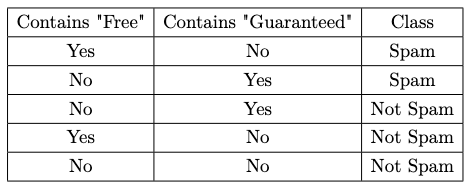

**Problem**:

You have received a new email that contains the words "**Free**" and "**Guaranteed**." You need to decide whether this email is spam or not.

We will follow the following steps to solve this problem.



####  Question 3a. Encoding features and labels [5]

Let us encode the dataset in a table with our features $X$ and labels $Y$.

|X(0) | X(1) | Y  |
|:---:|:----:|:--:|
|1 | 0 | 1 |
|0 | 1 | 1 |
|0 | 1 | 0 |
|1 | 0 | 0 |
|0 | 0 | 0 |


Each row in this table represents an entry from our email dataset. The first column, $X(0)$, indicates if an email contains the word "Free," and the second column, $X(1)$, indicates if an email contains the word "Guaranteed." We use a value of $1$ to indicate if an email contains a word and $0$ if it does not.

The labels, $Y$, **Spam** and **Not Spam** are also encoded as $1$ and $0$, respectively.


For example, the features in the first row in this table is encoded as $[1,0]$. Here, $[1, 0]$ indicates that the email contains "Free" (the first entry set to 1) and does not contain "Guaranteed" (the second entry set to 0). Similarly, the label for the row can be encoded as $[1]$ because the email is spam.

You can write the first row of the table using `numpy` as follows.

In [92]:
X = np.array([[1, 0]])  # Features of first row (Free/not guaranteed)
Y = np.array([1])       # First label (Spam)

Now, create X and Y by including all the rows from the table above.

In [93]:
# TODO: Create X and Y by including all the rows from the table dataset above.
X = np.append(X, [[0,1],  # not free, guaranteed
                  [0,1],  # not free, guaranteed
                  [1,0],  # free, not guaranteed
                  [0,0]], # not free, not guaranteed
                  axis=0) 

Y = np.append(Y, [1,   # Spam
                  0,   # Not Spam
                  0,   # Not Spam
                  0],  # Not Spam
                  axis=0)

print(X)
print(Y)

[[1 0]
 [0 1]
 [0 1]
 [1 0]
 [0 0]]
[1 1 0 0 0]


####  Question 3b. Calculate required probabilities [10]

Let us now compute the probabilities required for our Naive Bayes method:



**Naïve Bayes** methods are a set of supervised learning algorithms based on applying Bayes’ theorem with the “naïve” assumption of conditional independence between every pair of features given the value of the class variable. Bayes’ theorem states the following relationship, given class variable $y$ and dependent feature vector $x(1)$ through $x(d)$:

\begin{align*}
P(y | [x(1),\ldots, x(d)]) &\propto P([x(1),\ldots, x(d)] | y) P(y) \\
& = P(x(1)|y) \ldots P(x(d)|y) P(y) \\
& = P(y) \prod_{k=1}^d P(x(k)|y)
\end{align*}

The predicted class $\hat{y}$ is the one that maximizes the posterior probability, given by:

\begin{align*}
\hat{y} = \arg \max_{y} \left( P(y) \prod_{k=1}^{d} P(x(k) | y) \right)
\end{align*}


**1. Probabily of Spam $P(y =1 )$ and Not Spam $P(y=0)$**

To compute these probabilities, count the occurrences of each class in your label vector $y$.

$$
P(y=1) = \frac{\text{Number of Spam instances}}{\text{Total number of instances}}
$$

$$
P(y = 0 ) = \frac{\text{Number of Not Spam instances}}{\text{Total number of instances}} = 1 - P(y=1)
$$

These values represent the prior probabilities for the classes in our email dataset.



To count occurances of an element `k` in a given numpy array `data_points`, you can use the `np.sum(data_points==k)` function.

Here is an example that counts how many times the number `3` occurs in the list `[1, 2, 3, 3, 4, 3, 5]`.

In [94]:
import numpy as np

# Array representing data points
data_points = np.array([1, 2, 3, 3, 4, 3, 5])

# Count how many times the number 3 appears in data_points
count_three = np.sum(data_points == 3)

print(f"The number 3 appears {count_three} times")

The number 3 appears 3 times


Now, use the `np.sum()` function to count the number of spam and non spam instances to compute the probabilities.

In [95]:
# TODO compute py_0 (probability of not spam) and py_1 (probability of spam)

total_instances = len(Y)
not_spam_instances = np.sum(Y == 0)
spam_instances = np.sum(Y == 1)

py_0 = not_spam_instances / total_instances
py_1 = spam_instances / total_instances

print(f"p(y = 0): {py_0}, p(y = 1): {py_1}")

p(y = 0): 0.6, p(y = 1): 0.4



**2. Conditional probabilities**

Now, let us compute the conditional probabilities required for our Naive Bayes method for the "free" and "guaranteed" features.

You will need to compute these four conditional probabilities.

$$
P(x(0) = 1 | y = 1)
 = \frac{\text{Number of instances with free and Spam}}{\text{Number of Spam instances}}
$$


$$
P(x(0) = 1 | y = 0) = \frac{\text{Number of instances with free and Not Spam}}{\text{Number of Not Spam instances}}
$$

$$
P(x(1) = 1 | y = 1) = \frac{\text{Number of instances with guaranteed and Spam}}{\text{Number of Spam instances}}
$$

$$
P(x(1) = 1 | y = 0) = \frac{\text{Number of instances with guaranteed and Not Spam}}{\text{Number of Not Spam instances}}
$$



To count the number of occurrences in one array based on a condition in another array, you can use the following code.

In this example, we are counting the number of times `3` appears in `data_points` when the corresponding label is `0` or `1`.


In [96]:
import numpy as np

# Arrays representing data points and their corresponding labels
data_points = np.array([1, 2, 3, 3, 4, 3, 5])
labels = np.array([1, 0, 1, 1, 0, 0, 1])

# Count how many times the number 3 appears in data_points when the label is 0
count_three_when_label_is_0 = np.sum(data_points[labels == 0] == 3)

# Count how many times the number 3 appears in data_points when the label is 1
count_three_when_label_is_1 = np.sum(data_points[labels == 1] == 3)

print(f"The number three appears {count_three_when_label_is_0} time(s) when label == 0")
print(f"The number three appears {count_three_when_label_is_1} time(s) when label == 1")

The number three appears 1 time(s) when label == 0
The number three appears 2 time(s) when label == 1


Now, use a similar approach to calculate the conditional probabilities and print your results.

In [97]:
# TODO: From the variables X and Y, calculate and print the following probabilities

#P(x(0) = 1 | y = 1) i.e., P(free | spam)
p_free_spam = np.sum(X[Y == 1][:,0] == 1) / spam_instances

# P(x(0) = 1 | y = 0) i.e., P(free | not spam)
p_free_not_spam = np.sum(X[Y == 0][:,0] == 1) / not_spam_instances

# P(x(1) = 1 | y = 1) i.e., P(guaranteed | spam)
p_guaranteed_spam = np.sum(X[Y == 1][:,1] == 1) / spam_instances

# P(x(1) = 1 | y = 0) i.e., P(guaranteed | not spam)
p_guaranteed_not_spam = np.sum(X[Y == 0][:,1] == 1) / not_spam_instances


####  Question 3c. Perform prediction [10]

**Finally, let us use the conditional probabilities to build a naive bayes classifier that can predict class $\hat{y}$ given an input $X$.**

For instance, if $X = [1, 1]$ that implies both "free" and "guaranteed" are present. We would compare $P(y=1|x(0) = 1, x(1)=1)$ and $P(y=0|x(0) = 1, x(1)=1)$ to determine which outcome is more likely.

Using the probabilities you calculated in Q3b, define a `naivebayes` function that computes the following probabilities: $P(y=1), P (x(0)| y=1), P(x(1)| y=1)$

Note that under Naive Bayes assumption we can calculate the following terms
$$P(y=1|[x(0), x(1)]) \propto P(y=1) P (x(0)| y=1) P(x(1)| y=1)$$
and
$$P(y=0|[x(0), x(1)]) \propto P(y=0) P (x(0)| y=0) P(x(1)| y=0)$$

**After calculating these probabilities we can decide whether the email should be classified as 'Spam' (if P(y=1|[x(0),x(1)]) > P(y=1|[x(0),x(1)]))) or 'Not Spam' (otherwise).**


In [98]:
# TODO: Calculate the predicted values for all training samples

# predict labels on the training data
pred_labels = np.array([])

def naive_bayes(X, Y, test_data):
    # getting x0 and x1 from the test data
    x0, x1 = test_data
    #print(f"Test data: {test_data}")

    # let's first store P(y = 1) and P(y = 0):
    total_instances = len(Y)
    spam_instances = np.sum(Y == 1)
    not_spam_instances = np.sum(Y == 0)
    py_1 = spam_instances / total_instances
    py_0 = not_spam_instances / total_instances

    # let's store our conditional probabilities:
    prob_x0_given_y_1 = np.sum(X[Y == 1][:,0] == x0) / spam_instances
    prob_x0_given_y_0 = np.sum(X[Y == 0][:,0] == x0) / not_spam_instances

    prob_x1_given_y_1 = np.sum(X[Y == 1][:,1] == x1) / spam_instances
    prob_x1_given_y_0 = np.sum(X[Y == 0][:,1] == x1) / not_spam_instances

    # let's compute P(y = 0 | [x(0), x(1)] ) = P(y = 0) * P(x(0) | y = 0) * P(x(1) | y = 0)
    prob_y_0_given_x = py_0 * prob_x0_given_y_0 * prob_x1_given_y_0

    # let's now compute P(y = 1 | [x(0), x(1)] ) = P(y = 1) * P(x(0) | y = 1) * P(x(1) | y = 1)
    prob_y_1_given_x = py_1 * prob_x0_given_y_1 * prob_x1_given_y_1

    # we now want to return the label that has the highest probability
    return 1 if prob_y_1_given_x > prob_y_0_given_x else 0 # if the probability of spam is higher, we return 1, else 0

# let's test our naive bayes classifier on our training data
for sample in X:
    pred_labels = np.append(pred_labels, naive_bayes(X, Y, sample))
# Calculate errors the learned naive bayes classifier is making on the training set
accuracy = sum(Y == pred_labels)/len(Y)
print(f"Training accuracy: {accuracy}")

Training accuracy: 0.6


In [99]:
## Print whether the following emails should be spam or not spam
test_data = np.array([1, 1])

# predict labels on the test data
pred_label = naive_bayes(X, Y, test_data)

print(f"predicted label for [1,1]: {pred_label}")

predicted label for [1,1]: 1




---
## <font color='red'>  **Submission instructions**  
1. Download this Colab to ipynb, and convert it to PDF. Follow similar steps as [here](https://stackoverflow.com/questions/53460051/convert-ipynb-notebook-to-html-in-google-colab) but convert to PDF.
 - Download your .ipynb file. You can do it using only Google Colab. `File` -> `Download` -> `Download .ipynb`
 - Re-upload it so Colab can see it. Click on the `Files` icon on the far left to expand the side bar. You can directly drag the downloaded .ipynb file to the area. Or click `Upload to session storage` icon and then select & upload your .ipynb file.
 - Conversion using %%shell.
 ```
!sudo apt-get update
!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic pandoc
!pip install pypandoc
!jupyter nbconvert --log-level DEBUG --to pdf /path/to/notebook.ipynb
  ```
 - Your PDF file is ready. Click 3 dots and `Download`.


  

2. Upload the generated PDF file to Gradescope. Select the correct PDF pages for each question. Refer to week 1 discussion video or reach out to TAs if you face any issue.  **Important!**

3. Upload the .ipynb file to Gradescope.

4. Use **only this method** to convert notebook to PDF. **DO NOT** use other methods like `ctrl+p` or anything else.

6. Upload both the .ipynb file and the PDF file. **Important!**

**There will be deductions if you do not submit files properly.**

</font>

In [ ]:
!sudo apt-get update
!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic pandoc
!pip install pypandoc

In [ ]:
!jupyter nbconvert --log-level DEBUG --to pdf /path/to/notebook.ipynb # make sure the ipynb name is correct